# Proyek UAS Mata Kuliah Kecerdasan Buatan Training dataset Bahasa Isyarat menggunakan CNN+LSTM
Kelompok Rabu-4:
- Nama (NPM) 
- Nama (NPM) 
- Nama (NPM) 
- Nama (NPM) 

# 1. Import Dependency

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import sklearn
import tensorflow as tf
import os
import cv2
import time

import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


I0000 00:00:1779629721.065601   18726 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 1.1. Setting Tensorflow GPU

In [2]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# 2. Setup Open CV dan Mediapipe HandLanmarker

## 2.1. Inisialisasi Mediapipe HandLandmarker

In [3]:
# BaseOptions = mp.tasks.BaseOptions
# HandLandmarker = mp.tasks.vision.HandLandmarker
# HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
# VisionRunningMode = mp.tasks.vision.RunningMode

In [4]:
# options = HandLandmarkerOptions(
#     base_options=BaseOptions(model_asset_path='handlandmarker/hand_landmarker.task',
#                              delegate=BaseOptions.Delegate.GPU),
#     running_mode=VisionRunningMode.IMAGE,
#     num_hands=2) 

In [5]:
# def mediapipe_detection(image, model):
#     image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#     image.flags.writeable = False
#     results = model.detect(image)
#     image.flags.writeable = True
#     image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
#     return image, results

## 2.2. Inisialisasi OpenCV 2

In [6]:
# cap = cv2.VideoCapture(0, cv2.CAP_V4L2) # Setting Capture untuk di linux

# if not cap.isOpened():
#     print("Cannot open camera")
# else:
#     while cap.isOpened():

#         # membaca feed
#         ret, frame = cap.read()
        
#         if not ret or frame is None:
#             print("Camera/Frame error.")
#             break

#         # show feed
#         cv2.imshow('OpenCV Feed', frame)

#         if cv2.waitKey(10) & 0xFF == ord('q'):
#             break
# cap.release()
# cv2.destroyAllWindows()


# 3. Import Dataset

In [7]:
DATA_PATH = os.path.join('dataset')

# 4. Preprocessing Dataset

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Conv1D, MaxPooling1D
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
from tensorflow.keras.optimizers import Adam

In [9]:
video_frames = 90

In [10]:
actions = np.array([name for name in os.listdir(DATA_PATH) if os.path.isdir(os.path.join(DATA_PATH, name))])

label_map = {label:num for num, label in enumerate(actions)}

In [11]:
print("Daftar actions:", actions)
print("Label map:", label_map)

Daftar actions: ['Kita' 'Kamu' 'Siapa' 'Nunggu' 'Saya' 'Sudah' 'Hallo' 'Dimana'
 'Terima Kasih' 'Apa']
Label map: {np.str_('Kita'): 0, np.str_('Kamu'): 1, np.str_('Siapa'): 2, np.str_('Nunggu'): 3, np.str_('Saya'): 4, np.str_('Sudah'): 5, np.str_('Hallo'): 6, np.str_('Dimana'): 7, np.str_('Terima Kasih'): 8, np.str_('Apa'): 9}


## 4.1. Augmentasi Dataset

In [12]:
import numpy as np

def augment_sequence(sequence):
    augmented_sequences = []
    
    # 1. Jittering 1 (Noise kecil)
    noise1 = np.random.normal(0, 0.015, sequence.shape)
    augmented_sequences.append(sequence + noise1)
    
    # 2. Jittering 2 (Noise lebih besar)
    noise2 = np.random.normal(0, 0.025, sequence.shape)
    augmented_sequences.append(sequence + noise2)
    
    # 3. Scaling 1 (Pengecilan antara 0.85 sampai 0.95)
    scale_factor1 = np.random.uniform(0.85, 0.95)
    augmented_sequences.append(sequence * scale_factor1)
    
    # 4. Scaling 2 (Perbesaran antara 1.05 sampai 1.15)
    scale_factor2 = np.random.uniform(1.05, 1.15)
    augmented_sequences.append(sequence * scale_factor2)
    
    # 5. Kombinasi Jittering dan Scaling
    noise3 = np.random.normal(0, 0.02, sequence.shape)
    scale_factor3 = np.random.uniform(0.9, 1.1)
    seq_combo = (sequence + noise3) * scale_factor3
    augmented_sequences.append(seq_combo)
    
    # Total akan me-return 5 array augmentasi
    return augmented_sequences

In [13]:
sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    npy_files = [f for f in os.listdir(action_path) if f.endswith('.npy')]
    
    for npy_file in npy_files:
        res = np.load(os.path.join(action_path, npy_file))
        
        # Padding/Truncating ke "video_frames"
        if res.shape[0] < video_frames:
            pad_length = video_frames - res.shape[0]
            res = np.pad(res, ((0, pad_length), (0, 0)), mode='constant')
        else:
            res = res[:video_frames, :]
            
        # 1. Tambahkan data original terlebih dahulu
        sequences.append(res)
        labels.append(label_map[action])
        
        # 2. Opsional: Lakukan Augmentasi dan tambahkan data buatan ke dalam urutan list
        # Hati-hati: Melakukan augmentasi pada semua data akan melipatgandakan jumlah data dan RAM secara drastis
        aug_data = augment_sequence(res)
        for aug_res in aug_data:
            sequences.append(aug_res)
            labels.append(label_map[action])


In [14]:
np.array(sequences).shape

(3600, 90, 126)

In [15]:
np.array(labels).shape

(3600,)

In [16]:
print("Jumlah data sequences:", len(sequences))
print("Jumlah data labels:", len(labels))

Jumlah data sequences: 3600
Jumlah data labels: 3600


In [17]:
x = np.array(sequences)
y = to_categorical(labels).astype(int)
print("Shape x:", x.shape)
print("Shape y:", y.shape)

Shape x: (3600, 90, 126)
Shape y: (3600, 10)


In [18]:
x.shape

(3600, 90, 126)

In [19]:
# split train 60%, dev 20%, test 20%
X_temp, X_test, y_temp, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

X_train, X_dev, y_train, y_dev = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print("Shape of X_train:", X_train.shape)   # 60% data
print("Shape of y_train:", y_train.shape)

print("Shape of X_dev:", X_dev.shape)       # 20% data
print("Shape of y_dev:", y_dev.shape)

print("Shape of X_test:", X_test.shape)     # 20% data
print("Shape of y_test:", y_test.shape)

Shape of X_train: (2160, 90, 126)
Shape of y_train: (2160, 10)
Shape of X_dev: (720, 90, 126)
Shape of y_dev: (720, 10)
Shape of X_test: (720, 90, 126)
Shape of y_test: (720, 10)


# 5. Training Base Model

In [20]:
# 1. Definisikan Arsitektur CNN + LSTM
model = Sequential()

model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(90, 126)))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))
model.add(Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))

# LSTM Layers (untuk mempelajari Temporal/Sequence pergerakan titik waktu)
model.add(LSTM(64, return_sequences=True, activation='relu', recurrent_dropout=0.2))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=True, activation='relu', recurrent_dropout=0.2))
model.add(Dropout(0.2))
model.add(LSTM(64, return_sequences=False, activation='relu', recurrent_dropout=0.2))


# Dense Layers (Klasifikasi akhir)
num_classes = len(actions)
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))

opt = Adam(learning_rate=0.0001)
# Compile Model
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['categorical_accuracy'])
model.summary()


/home/izzanns/GitHub_Repo/CNN_LSTM_SignLanguageModel/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1779629746.233446   18726 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5249 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 90, 64)         │        24,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 45, 64)         │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 22, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 22, 64)         │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 22, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 142,250 (555.66 KB)

 Trainable params: 142,250 (555.66 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
log_dir = os.path.join('Logs')
os.makedirs(log_dir, exist_ok=True)

tb_callback = TensorBoard(log_dir=log_dir)
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train, 
    y_train, 
    validation_data=(X_dev, y_dev), 
    epochs=150,
    batch_size=32,
    callbacks=[tb_callback, early_stopping]
)

Epoch 1/150


I0000 00:00:1779629794.717025   18817 service.cc:153] XLA service 0x7521ac009060 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779629794.717040   18817 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070 Ti, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1779629794.844081   18817 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779629795.715638   18817 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1779629796.342422   18817 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_7039_rewritten_const_0_rearrange_0__.21.clone.clone.clone.clone.clone.sunk.clone.clone
I0000 00:00:1779629796.342587   18817 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_7039_grad_7409_const_0__.46.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:

 9/68 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - categorical_accuracy: 0.1543 - loss: 2.3048 

I0000 00:00:1779629808.772110   18817 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


65/68 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - categorical_accuracy: 0.1181 - loss: 2.3033

I0000 00:00:1779629811.199540   18816 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_7039_rewritten_const_0_rearrange_0__.21.clone.clone.clone.clone.clone.sunk.clone.clone
I0000 00:00:1779629811.199689   18816 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_7039_grad_7409_const_0__.46.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779629811.199864   18816 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_2_while_body_6674_grad_8204_const_0__.55.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779629811.200031   18816 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_while_body_6309_grad_8998_const_0__.64.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779629811.200187   18816 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_while_body_6309_rewritten_const_0_rearrange_0__.11.clone.clone.clone.clone.clone.sunk.clone.clone.clone
I0000 00:00:1779629

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - categorical_accuracy: 0.1182 - loss: 2.3031

I0000 00:00:1779629821.671636   18816 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_while_body_11882_const_0__.11.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779629821.671850   18816 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_2_while_body_12201_const_0__.16.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779629821.671995   18816 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_12520_const_0__.21.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779629821.693007   18816 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779629822.217832   19370 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_24', 12 bytes spill stores, 

68/68 ━━━━━━━━━━━━━━━━━━━━ 35s 245ms/step - categorical_accuracy: 0.1208 - loss: 2.2983 - val_categorical_accuracy: 0.1014 - val_loss: 2.2654
Epoch 2/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - categorical_accuracy: 0.1546 - loss: 2.1446 - val_categorical_accuracy: 0.2139 - val_loss: 2.1016
Epoch 3/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - categorical_accuracy: 0.2032 - loss: 2.0631 - val_categorical_accuracy: 0.1875 - val_loss: 2.0253
Epoch 4/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - categorical_accuracy: 0.2009 - loss: 2.0267 - val_categorical_accuracy: 0.2069 - val_loss: 1.9885
Epoch 5/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - categorical_accuracy: 0.2162 - loss: 1.9801 - val_categorical_accuracy: 0.2431 - val_loss: 1.9523
Epoch 6/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - categorical_accuracy: 0.2449 - loss: 1.9419 - val_categorical_accuracy: 0.3014 - val_loss: 1.9905
Epoch 7/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - categorical_accuracy: 0.2843 - loss: 1.9144 

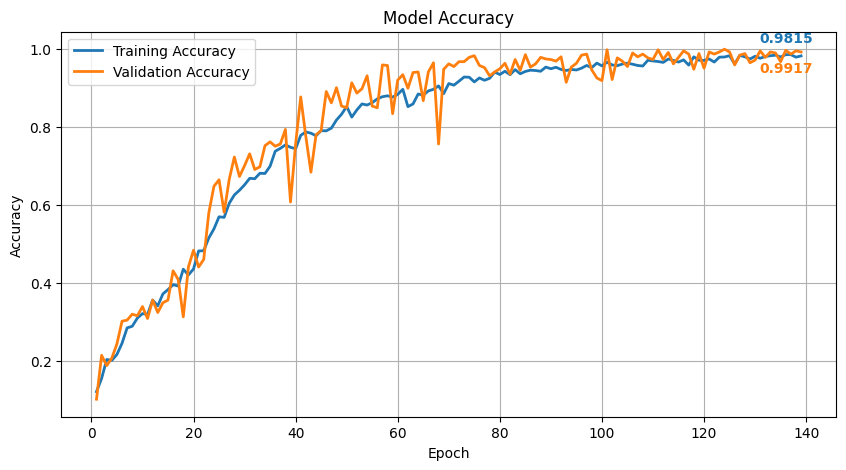

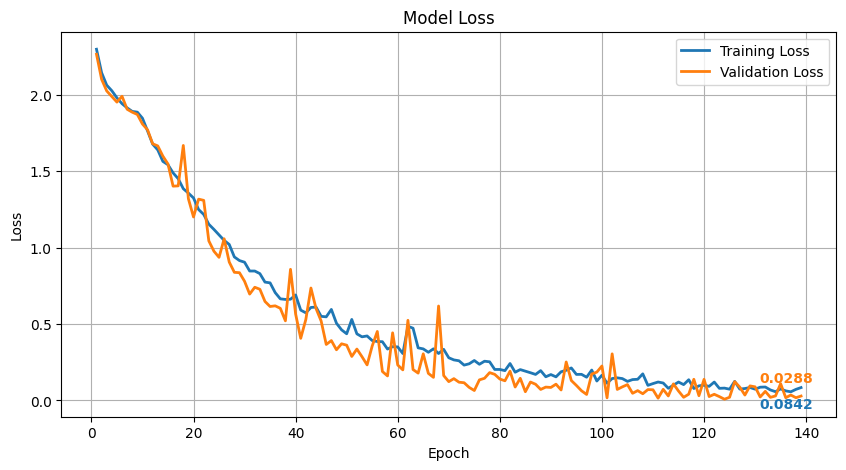

Final Training Accuracy:  0.9815
Final Validation Accuracy: 0.9917
Final Training Loss:       0.0842
Final Validation Loss:     0.0288


In [22]:
acc = history.history['categorical_accuracy']
val_acc = history.history['val_categorical_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Model Accuracy
plt.figure(figsize=(10,5))
plt.plot(epochs, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', linewidth=2)

# Anotasi hasil metrik di akhir plot akurasi
# C0 = Default Blue, C1 = Default Orange
plt.annotate(f'{acc[-1]:.4f}', xy=(epochs[-1], acc[-1]), xytext=(-30, 10), textcoords='offset points', color='C0', fontweight='bold')
plt.annotate(f'{val_acc[-1]:.4f}', xy=(epochs[-1], val_acc[-1]), xytext=(-30, -15), textcoords='offset points', color='C1', fontweight='bold')

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)  # Menambahkan background bergaris
plt.show()

# Plot Model Loss
plt.figure(figsize=(10,5))
plt.plot(epochs, loss, label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', linewidth=2)

# Anotasi hasil metrik di akhir plot loss
plt.annotate(f'{loss[-1]:.4f}', xy=(epochs[-1], loss[-1]), xytext=(-30, -15), textcoords='offset points', color='C0', fontweight='bold')
plt.annotate(f'{val_loss[-1]:.4f}', xy=(epochs[-1], val_loss[-1]), xytext=(-30, 10), textcoords='offset points', color='C1', fontweight='bold')

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)  # Menambahkan background bergaris
plt.show()

print(f"Final Training Accuracy:  {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Final Training Loss:       {loss[-1]:.4f}")
print(f"Final Validation Loss:     {val_loss[-1]:.4f}")

I0000 00:00:1779629991.407728   18817 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_while_body_155116_const_0__.9.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779629991.407958   18817 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_2_while_body_155431_const_0__.14.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779629991.408126   18817 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_155746_const_0__.19.clone.clone.clone.clone.clone.sunk.clone


 1/23 ━━━━━━━━━━━━━━━━━━━━ 31s 1s/step

I0000 00:00:1779629992.967163   18818 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_while_body_156222_const_0__.9.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779629992.967284   18818 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_1_2_while_body_156541_const_0__.14.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779629992.967377   18818 dot_merger.cc:481] Merging Dots in computation: sequential_1_lstm_2_1_while_body_156860_const_0__.19.clone.clone.clone.clone.clone.sunk.clone


23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step
================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

        Kita       1.00      1.00      1.00        93
        Kamu       1.00      1.00      1.00        73
       Siapa       0.99      1.00      0.99        79
      Nunggu       1.00      1.00      1.00        59
        Saya       1.00      0.95      0.97        81
       Sudah       0.95      1.00      0.98        63
       Hallo       1.00      1.00      1.00        68
      Dimana       1.00      1.00      1.00        69
Terima Kasih       1.00      1.00      1.00        68
         Apa       1.00      1.00      1.00        67

    accuracy                           0.99       720
   macro avg       0.99      1.00      0.99       720
weighted avg       0.99      0.99      0.99       720



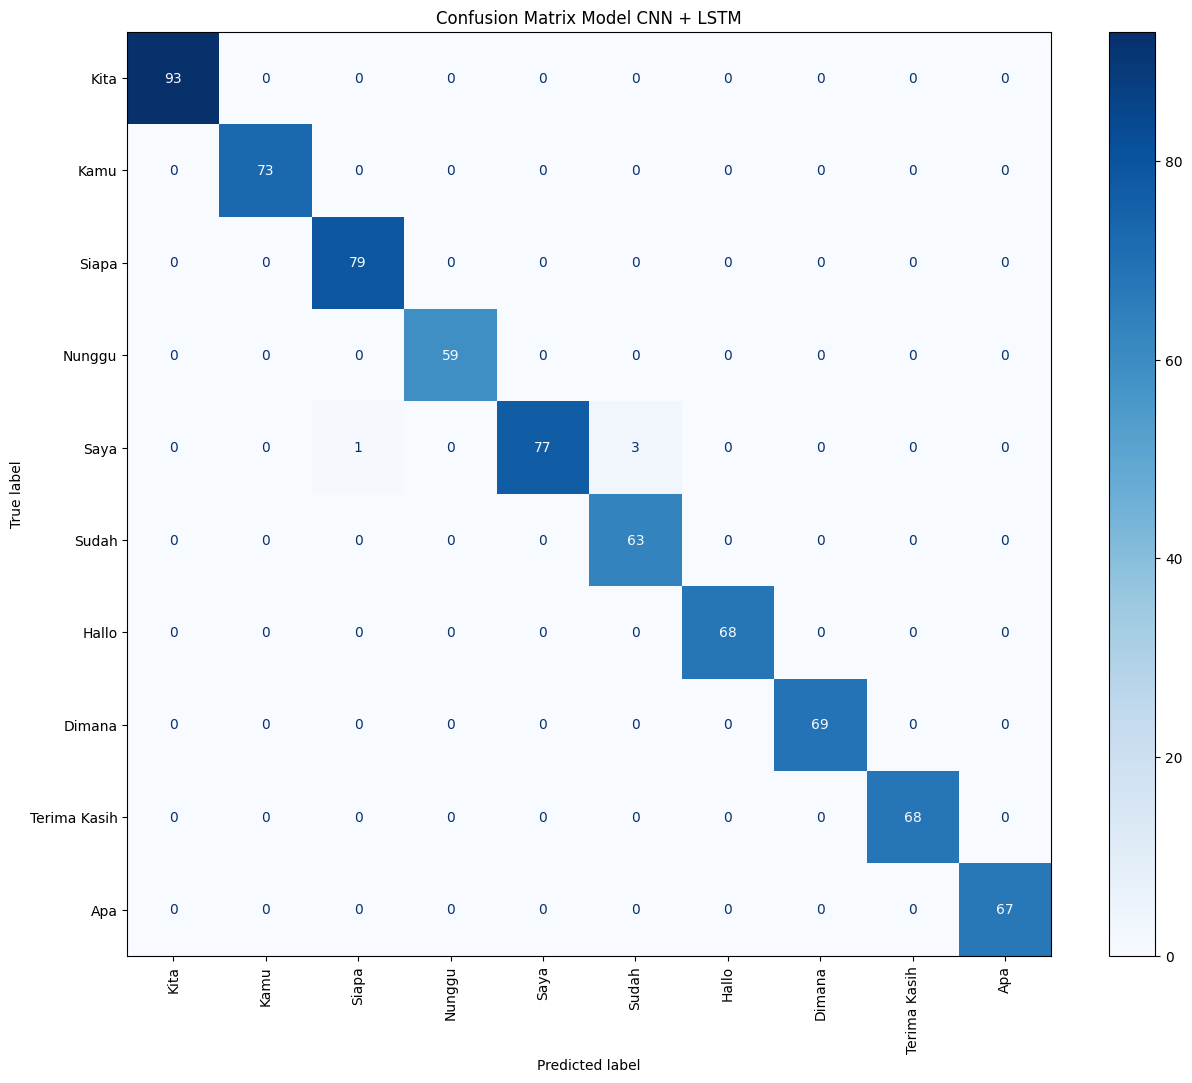

In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Lakukan prediksi pada data pengujian (X_test)
y_pred = model.predict(X_test)

# 2. Konversi hasil probabilitas/one-hot ke label indeks integer (0-25 untuk A-Z)
y_true_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Tambahkan argumen labels untuk memastikan semua 26 kelas (0 s.d 25) terhitung
label_indices = np.arange(len(actions))

# 3. Menampilkan Metrik Utama: Precision, Recall, F1-Score
print("================ CLASSIFICATION REPORT ================")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    labels=label_indices, 
    target_names=actions, 
    zero_division=0
))

# 4. Mendapatkan Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes, labels=label_indices)

# 5. Visualisasi Confusion Matrix dengan Matplotlib & scikit-learn
fig, ax = plt.subplots(figsize=(15, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=actions)

# Menyesuaikan label dan colormap
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix Model CNN + LSTM')
plt.show()

In [24]:
print("Mengevaluasi model pada Test Set...")
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)

print("\n=== HASIL EVALUASI TEST SET ===")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f} ({(test_accuracy*100):.2f}%)")

Mengevaluasi model pada Test Set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 0.9944 - loss: 0.0121

=== HASIL EVALUASI TEST SET ===
Test Loss     : 0.0121
Test Accuracy : 0.9944 (99.44%)


In [25]:
if not os.path.exists('base_model'):
    os.makedirs('base_model')
model.save('base_model/model_cnn_lstm_isyarat.keras')

# 6. Hyperparameter Tuning

## 6.1. Setup Tuner

In [26]:
import keras_tuner as kt

In [27]:
def build_model(hp):
    model = Sequential()
    
    # CNN 1
    hp_filters_1 = hp.Int('filters_1', min_value=32, max_value=128, step=32)
    model.add(Conv1D(filters=hp_filters_1, kernel_size=3, activation='relu', padding='same', input_shape=(90, 126)))
    model.add(MaxPooling1D(pool_size=2))

    # Dropout 1
    hp_dropout_1 = hp.Float('dropout_1', min_value=0.1, max_value=0.3, step=0.1)
    model.add(Dropout(hp_dropout_1))

    # CNN 2
    hp_filters_2 = hp.Int('filters_2', min_value=32, max_value=128, step=32)
    model.add(Conv1D(filters=hp_filters_2, kernel_size=3, activation='relu', padding='same'))
    model.add(MaxPooling1D(pool_size=2))

    # Dropout 2
    hp_dropout_2 = hp.Float('dropout_2', min_value=0.1, max_value=0.3, step=0.1)
    model.add(Dropout(hp_dropout_2))

    # LSTM 1
    hp_lstm_1 = hp.Int('lstm_1', min_value=32, max_value=128, step=32)
    hp_lstm_1_recurrent_dropout = hp.Float('lstm_1_recurrent_dropout', min_value=0.1, max_value=0.3, step=0.1)
    model.add(LSTM(hp_lstm_1, return_sequences=True, activation='relu', recurrent_dropout=hp_lstm_1_recurrent_dropout))

    # Dropout 3
    hp_dropout_3 = hp.Float('dropout_3', min_value=0.1, max_value=0.3, step=0.1)
    model.add(Dropout(hp_dropout_3))

    # LSTM 2
    hp_lstm_2 = hp.Int('lstm_2', min_value=32, max_value=128, step=32)
    hp_lstm_2_recurrent_dropout = hp.Float('lstm_2_recurrent_dropout', min_value=0.1, max_value=0.3, step=0.1)
    model.add(LSTM(hp_lstm_2, return_sequences=True, activation='relu', recurrent_dropout=hp_lstm_2_recurrent_dropout))
    
    # Dropout 4
    hp_dropout_4 = hp.Float('dropout_4', min_value=0.1, max_value=0.3, step=0.1)
    model.add(Dropout(hp_dropout_4))

    # LSTM 3
    hp_lstm_3 = hp.Int('lstm_3', min_value=64, max_value=256, step=64)
    hp_lstm_3_recurrent_dropout = hp.Float('lstm_3_recurrent_dropout', min_value=0.1, max_value=0.3, step=0.1)
    model.add(LSTM(hp_lstm_3, return_sequences=False, activation='relu', recurrent_dropout=hp_lstm_3_recurrent_dropout))

    # Dropout 5
    hp_dropout_5 = hp.Float('dropout_5', min_value=0.1, max_value=0.3, step=0.1)
    model.add(Dropout(hp_dropout_5))

    # Dense 1
    hp_dense_1 = hp.Int('dense_1', min_value=32, max_value=128, step=32)
    model.add(Dense(hp_dense_1, activation='relu'))

    # Dropout 6    
    hp_dropout_6 = hp.Float('dropout_6', min_value=0.1, max_value=0.3, step=0.1)
    model.add(Dropout(hp_dropout_6))

    # Dense 2
    hp_dense_2 = hp.Int('dense_2', min_value=32, max_value=128, step=32)
    model.add(Dense(hp_dense_2, activation='relu'))

    model.add(Dense(num_classes, activation='softmax'))

    # hp_learning_rate = hp.Float('learning_rate', min_value=1e-4, max_value=1e-2, sampling='log')
    optimizer = Adam(learning_rate=0.0001)

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['categorical_accuracy'])
        
    return model

In [28]:
tuner = kt.RandomSearch(
    build_model,
    objective='val_categorical_accuracy',
    # Ubah max_trials, semakin besar semakin optimal
    max_trials=100,
    executions_per_trial=1,
    directory='tuner_logs',
    project_name='cnn_lstm_sign_language',
    overwrite=True
)

/home/izzanns/GitHub_Repo/CNN_LSTM_SignLanguageModel/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 6.2. Melakukan Hyperparameter Tuning

In [29]:
tuner.search_space_summary()

early_stopping_tuner = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

tuner.search(
    X_train, 
    y_train, 
    validation_data=(X_dev, y_dev), 
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping_tuner]
)

Trial 100 Complete [00h 02m 04s]
val_categorical_accuracy: 0.9972222447395325

Best val_categorical_accuracy So Far: 1.0
Total elapsed time: 03h 05m 38s


In [30]:

best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"""
=== Pencarian Selesai! ===
Kombinasi Hyperparameter Terbaik Ditemukan:
- Filters Conv1D Pertama : {best_hps.get('filters_1')}
- Dropout 1              : {best_hps.get('dropout_1')}
- Filters Conv1D Kedua   : {best_hps.get('filters_2')}
- Dropout 2              : {best_hps.get('dropout_2')}
- Units LSTM Pertama     : {best_hps.get('lstm_1')}
- Dropout LSTM Pertama   : {best_hps.get('lstm_1_recurrent_dropout')}
- Dropout 3              : {best_hps.get('dropout_3')}
- Units LSTM Kedua       : {best_hps.get('lstm_2')}
- Dropout LSTM Kedua     : {best_hps.get('lstm_2_recurrent_dropout')}
- Dropout 4              : {best_hps.get('dropout_4')}
- Units LSTM Ketiga      : {best_hps.get('lstm_3')}
- Dropout LSTM Ketiga    : {best_hps.get('lstm_3_recurrent_dropout')}
- Dropout 5              : {best_hps.get('dropout_5')}
- Units Dense Pertama    : {best_hps.get('dense_1')}
- Dropout 6              : {best_hps.get('dropout_6')}
- Units Dense            : {best_hps.get('dense_2')}
- Learning Rate          : 0.001)


""")
best_model = tuner.get_best_models(num_models=1)[0]
best_model.summary()


=== Pencarian Selesai! ===
Kombinasi Hyperparameter Terbaik Ditemukan:
- Filters Conv1D Pertama : 32
- Dropout 1              : 0.1
- Filters Conv1D Kedua   : 128
- Dropout 2              : 0.1
- Units LSTM Pertama     : 32
- Dropout LSTM Pertama   : 0.1
- Dropout 3              : 0.2
- Units LSTM Kedua       : 96
- Dropout LSTM Kedua     : 0.1
- Dropout 4              : 0.1
- Units LSTM Ketiga      : 256
- Dropout LSTM Ketiga    : 0.1
- Dropout 5              : 0.1
- Units Dense Pertama    : 128
- Dropout 6              : 0.1
- Units Dense            : 32
- Learning Rate          : 0.001)





/home/izzanns/GitHub_Repo/CNN_LSTM_SignLanguageModel/.venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 40 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 90, 32)         │        12,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 45, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 45, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 45, 128)        │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 22, 32)         │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 22, 96)         │        49,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 22, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 256)            │       361,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 493,514 (1.88 MB)

 Trainable params: 493,514 (1.88 MB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# 1. Dapatkan hyperparameters terbaik
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

# 2. Bangun (build) ulang model dari hyperparameters terbaik
tuned_model = tuner.hypermodel.build(best_hps)

# 3. Lakukan training ulang (retrain) pada model tersebut untuk mendapatkan 'history'
print("Me-retrain model terbaik...")
history_tuned = tuned_model.fit(
    X_train, 
    y_train, 
    validation_data=(X_dev, y_dev), 
    epochs=150, # Gunakan jumlah epoch yang sama atau lebih
    batch_size=32,
    callbacks=[early_stopping_tuner] # Gunakan callback yang sama
)

Me-retrain model terbaik...
Epoch 1/150


I0000 00:00:1779641457.283066   18818 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_5_1_while_body_5320464_rewritten_const_0_rearrange_0__.21.clone.clone.clone.clone.clone.sunk.clone.clone
I0000 00:00:1779641457.283251   18818 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_5_1_while_body_5320464_grad_5320834_const_0__.46.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779641457.283459   18818 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_4_1_while_body_5320099_grad_5321629_const_0__.55.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779641457.283653   18818 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_3_1_while_body_5319734_grad_5322423_const_0__.64.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779641457.283832   18818 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_3_1_while_body_5319734_rewritten_const_0_rearrange_0__.11.clone.clone.clone.clone.clone.sunk

63/68 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - categorical_accuracy: 0.1158 - loss: 2.3021

I0000 00:00:1779641468.099745   18819 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_5_1_while_body_5320464_rewritten_const_0_rearrange_0__.21.clone.clone.clone.clone.clone.sunk.clone.clone
I0000 00:00:1779641468.100095   18819 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_5_1_while_body_5320464_grad_5320834_const_0__.46.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779641468.100339   18819 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_4_1_while_body_5320099_grad_5321629_const_0__.55.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779641468.100549   18819 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_3_1_while_body_5319734_grad_5322423_const_0__.64.clone.clone.clone.clone.clone.clone.clone
I0000 00:00:1779641468.100750   18819 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_3_1_while_body_5319734_rewritten_const_0_rearrange_0__.11.clone.clone.clone.clone.clone.sunk

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step - categorical_accuracy: 0.1153 - loss: 2.3020

I0000 00:00:1779641476.704348   18817 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_3_1_while_body_5324758_const_0__.11.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779641476.704524   18817 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_4_1_while_body_5325077_const_0__.16.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779641476.704664   18817 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_5_1_while_body_5325396_const_0__.21.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779641478.493902   18814 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_3_1_while_body_5324758_const_0__.11.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779641478.494104   18814 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_4_1_while_body_5325077_const_0__.16.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779641478.494251   18814 dot_merger.cc:481] Merging Dots in computation:

68/68 ━━━━━━━━━━━━━━━━━━━━ 31s 213ms/step - categorical_accuracy: 0.1079 - loss: 2.3006 - val_categorical_accuracy: 0.1931 - val_loss: 2.2915
Epoch 2/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - categorical_accuracy: 0.1898 - loss: 2.0944 - val_categorical_accuracy: 0.2139 - val_loss: 1.9800
Epoch 3/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - categorical_accuracy: 0.2528 - loss: 1.9701 - val_categorical_accuracy: 0.2583 - val_loss: 1.9219
Epoch 4/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - categorical_accuracy: 0.2787 - loss: 1.8860 - val_categorical_accuracy: 0.3417 - val_loss: 1.8100
Epoch 5/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - categorical_accuracy: 0.3542 - loss: 1.7279 - val_categorical_accuracy: 0.3347 - val_loss: 1.6787
Epoch 6/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - categorical_accuracy: 0.3884 - loss: 1.6386 - val_categorical_accuracy: 0.4806 - val_loss: 1.5112
Epoch 7/150
68/68 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - categorical_accuracy: 0.4222 - loss: 1.5235 

## 6.3. Analisis Model Terbaik Setelah Tuning

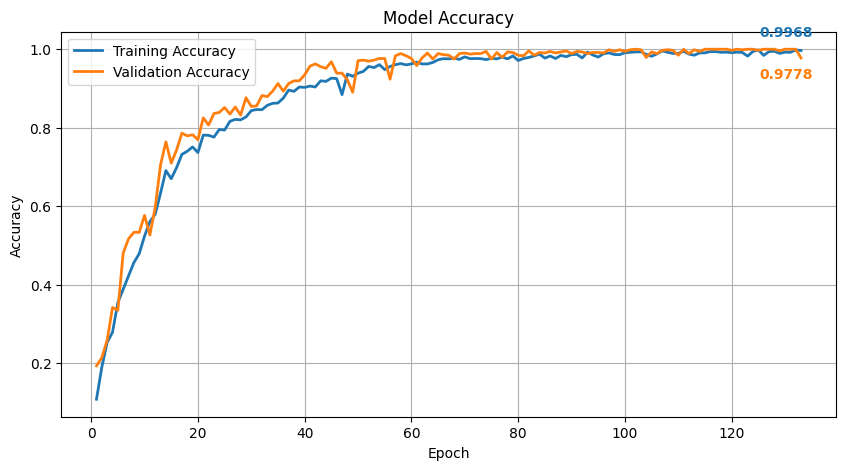

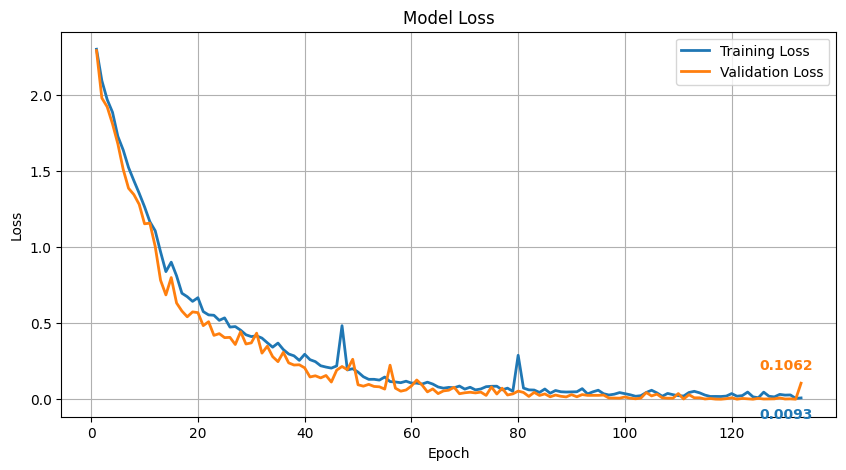

Final Training Accuracy:  0.9968
Final Validation Accuracy: 0.9778
Final Training Loss:       0.0093
Final Validation Loss:     0.1062


In [33]:
acc = history_tuned.history['categorical_accuracy']
val_acc = history_tuned.history['val_categorical_accuracy']
loss = history_tuned.history['loss']
val_loss = history_tuned.history['val_loss']

epochs = range(1, len(acc) + 1)

# Plot Model Accuracy
plt.figure(figsize=(10,5))
plt.plot(epochs, acc, label='Training Accuracy', linewidth=2)
plt.plot(epochs, val_acc, label='Validation Accuracy', linewidth=2)

# Anotasi hasil metrik di akhir plot akurasi
# C0 = Default Blue, C1 = Default Orange
plt.annotate(f'{acc[-1]:.4f}', xy=(epochs[-1], acc[-1]), xytext=(-30, 10), textcoords='offset points', color='C0', fontweight='bold')
plt.annotate(f'{val_acc[-1]:.4f}', xy=(epochs[-1], val_acc[-1]), xytext=(-30, -15), textcoords='offset points', color='C1', fontweight='bold')

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)  
plt.show()

# Plot Model Loss
plt.figure(figsize=(10,5))
plt.plot(epochs, loss, label='Training Loss', linewidth=2)
plt.plot(epochs, val_loss, label='Validation Loss', linewidth=2)

# Anotasi hasil metrik di akhir plot loss
plt.annotate(f'{loss[-1]:.4f}', xy=(epochs[-1], loss[-1]), xytext=(-30, -15), textcoords='offset points', color='C0', fontweight='bold')
plt.annotate(f'{val_loss[-1]:.4f}', xy=(epochs[-1], val_loss[-1]), xytext=(-30, 10), textcoords='offset points', color='C1', fontweight='bold')

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)  # Menambahkan background bergaris
plt.show()

print(f"Final Training Accuracy:  {acc[-1]:.4f}")
print(f"Final Validation Accuracy: {val_acc[-1]:.4f}")
print(f"Final Training Loss:       {loss[-1]:.4f}")
print(f"Final Validation Loss:     {val_loss[-1]:.4f}")

I0000 00:00:1779641716.820059   18818 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_3_1_while_body_5379669_const_0__.9.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779641716.820263   18818 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_4_1_while_body_5379984_const_0__.14.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779641716.820464   18818 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_5_1_while_body_5380299_const_0__.19.clone.clone.clone.clone.clone.sunk.clone


22/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

I0000 00:00:1779641718.994109   18817 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_3_1_while_body_5380775_const_0__.9.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779641718.994285   18817 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_4_1_while_body_5381094_const_0__.14.clone.clone.clone.clone.clone.sunk.clone
I0000 00:00:1779641718.994465   18817 dot_merger.cc:481] Merging Dots in computation: sequential_1_1_lstm_5_1_while_body_5381413_const_0__.19.clone.clone.clone.clone.clone.sunk.clone


23/23 ━━━━━━━━━━━━━━━━━━━━ 4s 94ms/step
================ CLASSIFICATION REPORT ================
              precision    recall  f1-score   support

        Kita       1.00      1.00      1.00        93
        Kamu       1.00      1.00      1.00        73
       Siapa       1.00      1.00      1.00        79
      Nunggu       1.00      1.00      1.00        59
        Saya       1.00      1.00      1.00        81
       Sudah       1.00      1.00      1.00        63
       Hallo       1.00      1.00      1.00        68
      Dimana       1.00      1.00      1.00        69
Terima Kasih       1.00      1.00      1.00        68
         Apa       1.00      1.00      1.00        67

    accuracy                           1.00       720
   macro avg       1.00      1.00      1.00       720
weighted avg       1.00      1.00      1.00       720



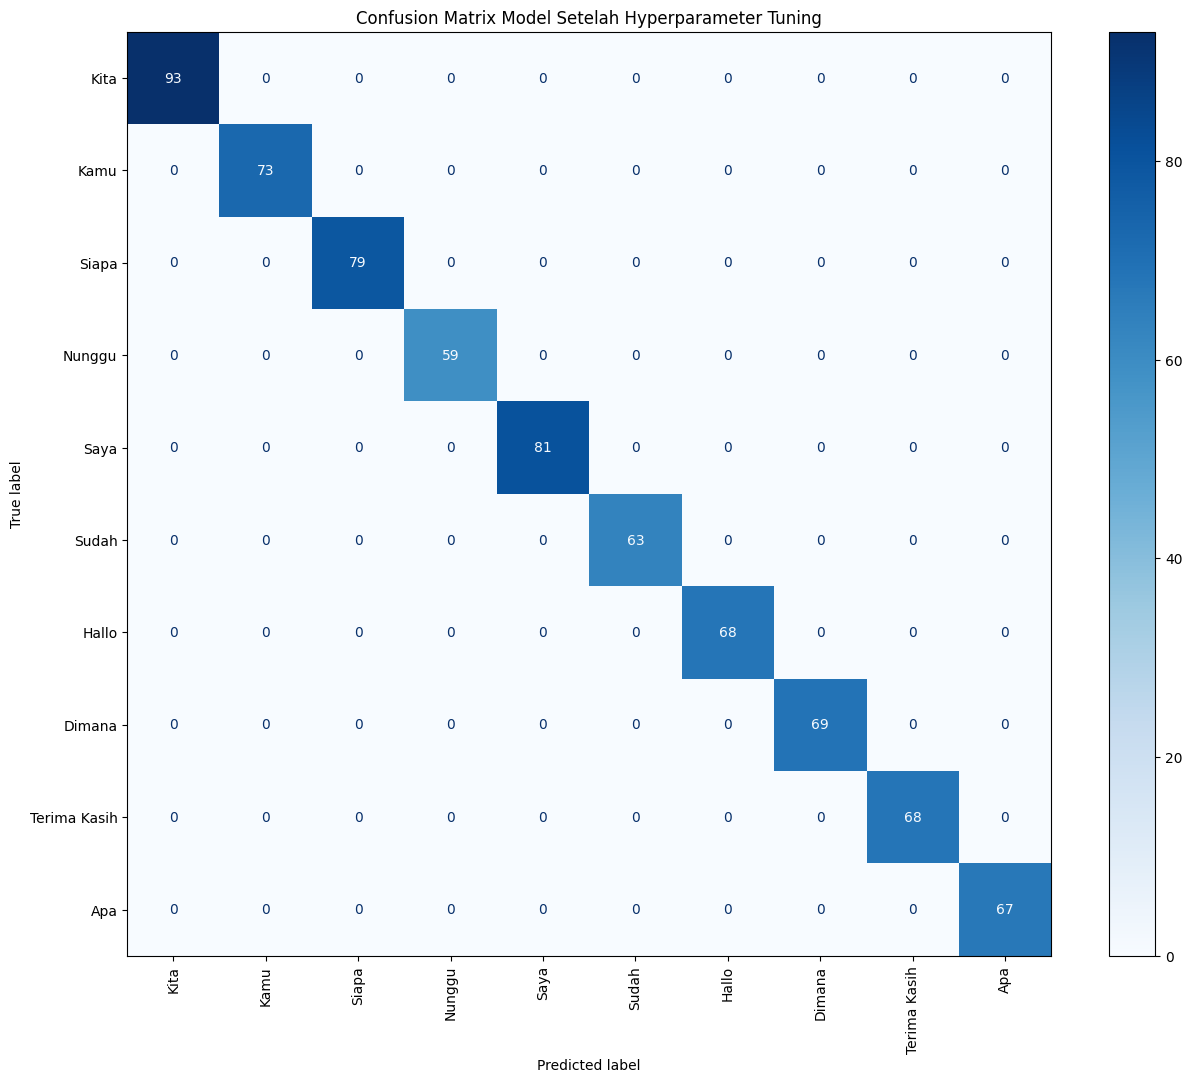

In [34]:
# 1. Lakukan prediksi pada data pengujian (X_test)
y_pred = tuned_model.predict(X_test)

y_true_classes = np.argmax(y_test, axis=1)
y_pred_classes = np.argmax(y_pred, axis=1)

# Tambahkan argumen labels untuk memastikan semua 26 kelas (0 s.d 25) terhitung
label_indices = np.arange(len(actions))

# 3. Menampilkan Metrik Utama: Precision, Recall, F1-Score
print("================ CLASSIFICATION REPORT ================")
print(classification_report(
    y_true_classes, 
    y_pred_classes, 
    labels=label_indices, 
    target_names=actions, 
    zero_division=0
))

# 4. Mendapatkan Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes, labels=label_indices)

# 5. Visualisasi Confusion Matrix dengan Matplotlib & scikit-learn
fig, ax = plt.subplots(figsize=(15, 12))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=actions)

# Menyesuaikan label dan colormap
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical')
plt.title('Confusion Matrix Model Setelah Hyperparameter Tuning')
plt.show()

In [35]:
print("Mengevaluasi model pada Test Set...")
test_loss, test_accuracy = tuned_model.evaluate(X_test, y_test, verbose=1)

print("\n=== HASIL EVALUASI TEST SET ===")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f} ({(test_accuracy*100):.2f}%)")

Mengevaluasi model pada Test Set...
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - categorical_accuracy: 1.0000 - loss: 0.0014   

=== HASIL EVALUASI TEST SET ===
Test Loss     : 0.0014
Test Accuracy : 1.0000 (100.00%)


## 6.2. Simpan Model Terbaik

In [36]:
if not os.path.exists('best_model'):
    os.makedirs('best_model')
best_model.save('best_model/model_cnn_lstm_isyarat.keras')